In [178]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as norm
from matplotlib import RcParams
import warnings
warnings.filterwarnings('ignore')

In [179]:
layoffs = pd.read_excel(r'D:\FSDA\My Data Analysis\Data\India Layoff dataset\India_layoffs.xlsx')

# DATA READING

In [180]:
layoffs.head()

,Emp ID,Year,Company Name,Designation of Layoff,Gender,Qualification,Reason,State,Years of Experience,Fresher or Experienced,Department
0,EMP100095,2024,Flipkart,QA Engineer,Male,B.E.,Workforce restructuring,Odisha,15.0,Experienced,Engineering
1,EMP100102,2024,Infosys,Reporting Analyst,Non-binary,Diploma,Market demand decline,Gujarat,15.0,Experienced,Analytics
2,EMP100159,2024,PhonePe,Recruiter,Male,M.Tech,Workforce restructuring,Rajasthan,15.0,Experienced,Human Resources
3,EMP100364,2024,Microsoft,Growth Manager,Non-binary,B.E.,Financial pressure,Maharashtra,15.0,Experienced,Marketing
4,EMP100920,2024,Udaan,Business Analyst,Female,B.Tech,Cost reduction,Karnataka,15.0,Experienced,Analytics


In [181]:
layoffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4550 entries, 0 to 4549
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Emp ID                  4550 non-null   object 
 1   Year                    4550 non-null   int64  
 2   Company Name            4550 non-null   object 
 3   Designation of Layoff   4530 non-null   object 
 4   Gender                  4504 non-null   object 
 5   Qualification           4510 non-null   object 
 6   Reason                  4535 non-null   object 
 7   State                   4514 non-null   object 
 8   Years of Experience     4520 non-null   float64
 9   Fresher or Experienced  4550 non-null   object 
 10  Department              4525 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 391.1+ KB


In [182]:
layoffs.describe(include ='object')

,Emp ID,Company Name,Designation of Layoff,Gender,Qualification,Reason,State,Fresher or Experienced,Department
count,4550,4550,4530,4504,4510,4535,4514,4550,4525
unique,4550,39,47,3,11,10,15,2,10
top,EMP100095,Wipro,Admin Executive,Non-binary,M.Com,Business restructuring,Maharashtra,Experienced,Human Resources
freq,1,233,148,1570,458,471,330,4191,485


In [183]:
layoffs.describe()

,Year,Years of Experience
count,4550.000000,4520.000000
mean,2024.995604,5.210177
std,0.823099,3.600679
min,2024.000000,0.000000
25%,2024.000000,2.000000
50%,2025.000000,5.000000
75%,2026.000000,8.000000
max,2026.000000,15.000000


In [184]:
layoffs.dtypes.to_frame().rename(columns = {0 :'Data Types'})

,Data Types
Emp ID,object
Year,int64
Company Name,object
Designation of Layoff,object
Gender,object
Qualification,object
Reason,object
State,object
Years of Experience,float64
Fresher or Experienced,object


In [185]:
layoffs['Company Name'].value_counts().head().to_frame()

,count
Company Name,
Wipro,233
Infosys,223
Ola Electric,220
Paytm,219
Amazon,216


In [186]:
layoffs.isnull().sum().to_frame()

,0
Emp ID,0
Year,0
Company Name,0
Designation of Layoff,20
Gender,46
Qualification,40
Reason,15
State,36
Years of Experience,30
Fresher or Experienced,0


# DATA VALIDATION

In [187]:
layoffs['Designation of Layoff'].mode()[0]

'Admin Executive'

In [188]:
layoffs['Gender'].mode()[0]

'Non-binary'

In [189]:
layoffs['Qualification'].mode()[0]

'M.Com'

In [190]:
layoffs['Reason'].mode()[0]

'Business restructuring'

In [191]:
layoffs['State'].mode()[0]

'Maharashtra'

In [192]:
layoffs['Years of Experience'].median()

5.0

In [193]:
layoffs['Department'].mode()[0]

'Human Resources'

# FEATURE ENGINEERING

In [194]:
layoffs['Designation of Layoff'].fillna(layoffs['Designation of Layoff'].mode()[0], inplace = True)

In [195]:
layoffs['Gender'].fillna(layoffs['Gender'].mode()[0], inplace=True)

In [196]:
layoffs['Qualification'].fillna(layoffs['Qualification'].mode()[0], inplace = True)

In [197]:
layoffs['Reason'].fillna(layoffs['Reason'].mode()[0], inplace = True)

In [198]:
layoffs['State'].fillna(layoffs['State'].mode()[0], inplace = True)

In [199]:
layoffs['Years of Experience'].fillna(layoffs['Years of Experience'].median(), inplace=True)

In [200]:
layoffs['Department'].fillna(layoffs['Department'].mode()[0], inplace=True)

In [201]:
layoffs.isnull().sum()

Emp ID                    0
Year                      0
Company Name              0
Designation of Layoff     0
Gender                    0
Qualification             0
Reason                    0
State                     0
Years of Experience       0
Fresher or Experienced    0
Department                0
dtype: int64

In [202]:
layoffs.head(1)

,Emp ID,Year,Company Name,Designation of Layoff,Gender,Qualification,Reason,State,Years of Experience,Fresher or Experienced,Department
0,EMP100095,2024,Flipkart,QA Engineer,Male,B.E.,Workforce restructuring,Odisha,15.0,Experienced,Engineering


# MERGING 2 DATA FRAMES

In [203]:
emp_df = pd.read_excel(r'D:\FSDA\My Data Analysis\Data\India Layoff dataset\EMP DETAILS.xlsx')

In [204]:
df = pd.merge(layoffs, emp_df, on = 'Emp ID')
df.head()

,Emp ID,Year,Company Name,Designation of Layoff,Gender,Qualification,Reason,State,Years of Experience,Fresher or Experienced,...,DOJ,DOE,Department_y,Performance Rating,Work Mode,City,Manager ID,Training Hours,Overtime Hours,Attrition Risk
0,EMP100095,2024,Flipkart,QA Engineer,Male,B.E.,Workforce restructuring,Odisha,15.0,Experienced,...,2017-05-24,2024-04-24,Support,2.8,Remote,Chennai,MGR1095,21,43,High
1,EMP100102,2024,Infosys,Reporting Analyst,Non-binary,Diploma,Market demand decline,Gujarat,15.0,Experienced,...,2017-01-17,2026-03-02,Support,3.6,WFO,Pune,MGR1102,71,56,Low
2,EMP100159,2024,PhonePe,Recruiter,Male,M.Tech,Workforce restructuring,Rajasthan,15.0,Experienced,...,2021-02-11,2026-07-22,IT,4.8,WFO,Bengaluru,MGR1009,75,37,Medium
3,EMP100364,2024,Microsoft,Growth Manager,Non-binary,B.E.,Financial pressure,Maharashtra,15.0,Experienced,...,2022-05-10,2025-04-01,Sales,3.0,Hybrid,Delhi,MGR1064,19,17,Low
4,EMP100920,2024,Udaan,Business Analyst,Female,B.Tech,Cost reduction,Karnataka,15.0,Experienced,...,2019-05-28,2025-09-19,Operations,4.6,Remote,Bengaluru,MGR1020,11,41,High


In [205]:
df.isna().sum()

Emp ID                    0
Year                      0
Company Name              0
Designation of Layoff     0
Gender                    0
Qualification             0
Reason                    0
State                     0
Years of Experience       0
Fresher or Experienced    0
Department_x              0
Emp Name                  0
Emp Salary                0
DOJ                       0
DOE                       0
Department_y              0
Performance Rating        0
Work Mode                 0
City                      0
Manager ID                0
Training Hours            0
Overtime Hours            0
Attrition Risk            0
dtype: int64

In [206]:
df.dtypes

Emp ID                            object
Year                               int64
Company Name                      object
Designation of Layoff             object
Gender                            object
Qualification                     object
Reason                            object
State                             object
Years of Experience              float64
Fresher or Experienced            object
Department_x                      object
Emp Name                          object
Emp Salary                         int64
DOJ                       datetime64[ns]
DOE                       datetime64[ns]
Department_y                      object
Performance Rating               float64
Work Mode                         object
City                              object
Manager ID                        object
Training Hours                     int64
Overtime Hours                     int64
Attrition Risk                    object
dtype: object

# Feature Engineering

In [207]:
df.rename(columns={'Department_x':'Department', 'Department_y':'Branch','Designation of Layoff':'Designation'}, inplace=True)

In [208]:
df['Year Of Joining'] = df['DOJ'].dt.year
df.head()

,Emp ID,Year,Company Name,Designation,Gender,Qualification,Reason,State,Years of Experience,Fresher or Experienced,...,DOE,Branch,Performance Rating,Work Mode,City,Manager ID,Training Hours,Overtime Hours,Attrition Risk,Year Of Joining
0,EMP100095,2024,Flipkart,QA Engineer,Male,B.E.,Workforce restructuring,Odisha,15.0,Experienced,...,2024-04-24,Support,2.8,Remote,Chennai,MGR1095,21,43,High,2017
1,EMP100102,2024,Infosys,Reporting Analyst,Non-binary,Diploma,Market demand decline,Gujarat,15.0,Experienced,...,2026-03-02,Support,3.6,WFO,Pune,MGR1102,71,56,Low,2017
2,EMP100159,2024,PhonePe,Recruiter,Male,M.Tech,Workforce restructuring,Rajasthan,15.0,Experienced,...,2026-07-22,IT,4.8,WFO,Bengaluru,MGR1009,75,37,Medium,2021
3,EMP100364,2024,Microsoft,Growth Manager,Non-binary,B.E.,Financial pressure,Maharashtra,15.0,Experienced,...,2025-04-01,Sales,3.0,Hybrid,Delhi,MGR1064,19,17,Low,2022
4,EMP100920,2024,Udaan,Business Analyst,Female,B.Tech,Cost reduction,Karnataka,15.0,Experienced,...,2025-09-19,Operations,4.6,Remote,Bengaluru,MGR1020,11,41,High,2019


In [209]:
df['Experience'] = df['Year'] - df['Year Of Joining']
df['Experience Level'] = np.where(df['Experience'] == 0,'Fresher','Experienced')
df

,Emp ID,Year,Company Name,Designation,Gender,Qualification,Reason,State,Years of Experience,Fresher or Experienced,...,Performance Rating,Work Mode,City,Manager ID,Training Hours,Overtime Hours,Attrition Risk,Year Of Joining,Experience,Experience Level
0,EMP100095,2024,Flipkart,QA Engineer,Male,B.E.,Workforce restructuring,Odisha,15.0,Experienced,...,2.8,Remote,Chennai,MGR1095,21,43,High,2017,7,Experienced
1,EMP100102,2024,Infosys,Reporting Analyst,Non-binary,Diploma,Market demand decline,Gujarat,15.0,Experienced,...,3.6,WFO,Pune,MGR1102,71,56,Low,2017,7,Experienced
2,EMP100159,2024,PhonePe,Recruiter,Male,M.Tech,Workforce restructuring,Rajasthan,15.0,Experienced,...,4.8,WFO,Bengaluru,MGR1009,75,37,Medium,2021,3,Experienced
3,EMP100364,2024,Microsoft,Growth Manager,Non-binary,B.E.,Financial pressure,Maharashtra,15.0,Experienced,...,3.0,Hybrid,Delhi,MGR1064,19,17,Low,2022,2,Experienced
4,EMP100920,2024,Udaan,Business Analyst,Female,B.Tech,Cost reduction,Karnataka,15.0,Experienced,...,4.6,Remote,Bengaluru,MGR1020,11,41,High,2019,5,Experienced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4545,EMP102672,2026,Ola Electric,Accountant,Non-binary,Diploma,Role redundancy,Delhi,5.0,Experienced,...,3.9,Remote,Pune,MGR1122,10,31,Low,2024,2,Experienced
4546,EMP102750,2026,Meta,Sales Executive,Non-binary,BBA,Role redundancy,Karnataka,5.0,Experienced,...,3.0,Remote,Bengaluru,MGR1050,9,37,High,2020,6,Experienced
4547,EMP103695,2026,Zupee,MIS Executive,Female,MBA,Cost reduction,West Bengal,5.0,Experienced,...,2.9,Hybrid,Pune,MGR1095,15,49,Low,2017,9,Experienced
4548,EMP104511,2026,Flipkart,QA Engineer,Non-binary,Diploma,Market demand decline,Haryana,5.0,Experienced,...,3.6,Hybrid,Hyderabad,MGR1011,3,41,High,2018,8,Experienced


In [210]:
df.columns

Index(['Emp ID', 'Year', 'Company Name', 'Designation', 'Gender',
       'Qualification', 'Reason', 'State', 'Years of Experience',
       'Fresher or Experienced', 'Department', 'Emp Name', 'Emp Salary', 'DOJ',
       'DOE', 'Branch', 'Performance Rating', 'Work Mode', 'City',
       'Manager ID', 'Training Hours', 'Overtime Hours', 'Attrition Risk',
       'Year Of Joining', 'Experience', 'Experience Level'],
      dtype='object')

In [211]:
df.rename(columns = {'Year':'Year Of Exit'}, inplace = True)
df.drop(columns = ['Years of Experience','Fresher or Experienced','DOJ','DOE','City'], inplace = True)
df.columns

Index(['Emp ID', 'Year Of Exit', 'Company Name', 'Designation', 'Gender',
       'Qualification', 'Reason', 'State', 'Department', 'Emp Name',
       'Emp Salary', 'Branch', 'Performance Rating', 'Work Mode', 'Manager ID',
       'Training Hours', 'Overtime Hours', 'Attrition Risk', 'Year Of Joining',
       'Experience', 'Experience Level'],
      dtype='object')

-----------------------------------------------------------------------------------------------

# DATA ANALYSIS

## Attrition & Layoffs
   
* What are the top 3 departments with the highest layoff count?
* What is the breakdown of Reason for layoff across different State locations?
* Which Work Mode (Remote, Hybrid, Onsite) has the highest percentage of employees flagged with high Attrition Risk?
* Is there a higher layoff rate among employees with less than 2 years of experience compared to senior staff?

In [212]:
df['Department'].value_counts().reset_index().rename(columns = {'Emp ID':'Attrition'})

,Department,count
0,Human Resources,510
1,Sales,468
2,Engineering,465
3,Marketing,465
4,Finance,458
5,Product,443
6,Customer Support,443
7,Administration,437
8,Operations,434
9,Analytics,427


In [213]:
df.groupby('State')['Reason'].value_counts().to_frame()

count
State          Reason                        
Andhra Pradesh Role redundancy             42
               Cost reduction              40
               Market demand decline       35
               Project closure             32
               Workforce restructuring     31
...                                       ...
West Bengal    Cost reduction              29
               Financial pressure          29
               Role redundancy             28
               Market demand decline       25
               Workforce restructuring     25

[150 rows x 1 columns]

In [214]:
at_risk = df[df['Attrition Risk'] == 'High']
at_risk['Work Mode'].value_counts().to_frame().rename(columns = {'count':'High Risk'})

,High Risk
Work Mode,
WFO,541
Remote,499
Hybrid,486


In [215]:
exp_lt_2_yrs = df['Experience'][df['Experience'] < 2].count()
exp_of_2_yrs = df['Experience'][df['Experience'] >= 2].count()

print('STATEMENT :')
print(f'\nTOTAL NUMBER OF CANDIDATES LAIDOFF WITHIN 2 YEARS OF EXPERIENCE ARE : {exp_lt_2_yrs}\nTOTAL NUMBER OF CANDIDATES LAIDOFF WITH 2 OR MORE YEARS OF EXPERIENCE ARE : {exp_of_2_yrs}')

STATEMENT :

TOTAL NUMBER OF CANDIDATES LAIDOFF WITHIN 2 YEARS OF EXPERIENCE ARE : 461
TOTAL NUMBER OF CANDIDATES LAIDOFF WITH 2 OR MORE YEARS OF EXPERIENCE ARE : 4089


## 2. Compensation & Pay Equity
   
* What is the average and median Emp Salary for each Gender within the same Department and Qualification level?
* Which 5 States have the highest average salary for experienced employees?
* What is the salary gap between Fresher and Experienced employees across different departments?
* Are employees with high Overtime Hours earning significantly higher salaries, or is overtime uncompensated across certain departments?

In [216]:
df.groupby(['Department','Qualification','Gender'])['Emp Salary'].agg({'mean','median'}).round().reset_index()

,Department,Qualification,Gender,mean,median
0,Administration,B.E.,Female,998141.0,971772.0
1,Administration,B.E.,Male,1516743.0,1638216.0
2,Administration,B.E.,Non-binary,1430594.0,1547346.0
3,Administration,B.Sc,Female,1621512.0,1911828.0
4,Administration,B.Sc,Male,1035297.0,1013927.0
...,...,...,...,...,...
325,Sales,MBA,Male,1118203.0,1121991.0
326,Sales,MBA,Non-binary,975015.0,816636.0
327,Sales,MCA,Female,1009073.0,967543.0
328,Sales,MCA,Male,1146547.0,1135763.0


In [217]:
exp_emp = df[df['Experience Level'] == 'Experienced']
exp_emp = exp_emp.groupby('State')['Emp Salary'].mean().round().sort_values(ascending = False).head().reset_index()
exp_emp.rename(columns = {'Emp Salary':'Highest Avg Salary'})

,State,Highest Avg Salary
0,Karnataka,1281229.0
1,Rajasthan,1250518.0
2,Maharashtra,1246143.0
3,Telangana,1236630.0
4,West Bengal,1235553.0


In [218]:
main_frame_1 = df[['Department','Experience','Experience Level','Emp Salary']]
gap_analysis = main_frame_1.groupby(['Department','Experience Level'])['Emp Salary'].min().round().unstack()
gap_analysis['Gap'] = gap_analysis['Experienced'] - gap_analysis['Fresher']
gap_analysis

Experience Level,Experienced,Fresher,Gap
Department,,,
Administration,259025,439576,-180551
Analytics,253143,491944,-238801
Customer Support,251868,403960,-152092
Engineering,253068,283918,-30850
Finance,252745,250082,2663
Human Resources,251216,270453,-19237
Marketing,253367,428853,-175486
Operations,271560,446409,-174849
Product,252243,426214,-173971


In [219]:
OT_analysis = df.groupby('Department')[['Overtime Hours','Emp Salary']].mean().round()
OT_analysis.sort_values(by = 'Overtime Hours', ascending=False)

,Overtime Hours,Emp Salary
Department,,
Operations,31.0,1234166.0
Administration,30.0,1224412.0
Customer Support,30.0,1223086.0
Engineering,30.0,1238099.0
Finance,30.0,1253986.0
Human Resources,30.0,1254217.0
Sales,30.0,1214803.0
Analytics,29.0,1145623.0
Marketing,29.0,1187192.0


## 3. Burnout & Performance
   
* What is the correlation between Overtime Hours and Performance Rating?
* Which department has the highest average Overtime Hours paired with a Performance Rating below 3.0?
* Do employees who log more than 40 Training Hours per year show higher average Performance Rating scores?
* Does Work Mode significantly impact an employee's average Performance Rating?

In [220]:
df[['Overtime Hours', 'Performance Rating']].corr().round(3)

,Overtime Hours,Performance Rating
Overtime Hours,1.000,-0.021
Performance Rating,-0.021,1.000


In [221]:
pr_lt_3 = df[df['Performance Rating'] < 3]
pr_lt_3.groupby('Department')['Overtime Hours'].mean().sort_values(ascending = False).to_frame()

,Overtime Hours
Department,
Finance,33.389706
Sales,31.398734
Operations,30.874074
Product,30.216783
Engineering,29.541096
Customer Support,29.172662
Human Resources,28.886076
Administration,28.704698
Marketing,28.442029


In [222]:
t_mt_40 = df[df['Training Hours']>40]['Performance Rating'].mean().round(2)
overall_pf = df['Performance Rating'].mean().round(2)

print(f'Overall Average of Performance rating {overall_pf}\nAverage Performance Rating of the Training Hours more than 40 {t_mt_40}\n')

Overall Average of Performance rating 3.51
Average Performance Rating of the Training Hours more than 40 3.52



In [223]:
df.groupby('Work Mode')['Performance Rating'].mean().sort_values(ascending = False).reset_index()

,Work Mode,Performance Rating
0,WFO,3.525636
1,Remote,3.504784
2,Hybrid,3.486212


## 4. Organizational & Managerial Metrics

* Which Manager ID has the highest number of direct reports assigned to them?
* Which managers have more than 30% of their direct reports categorized under high Attrition Risk?

In [224]:
df['Manager ID'].value_counts().sort_values(ascending = False).reset_index().head()

,Manager ID,count
0,MGR1025,31
1,MGR1016,31
2,MGR1023,31
3,MGR1017,31
4,MGR1021,31


In [225]:
m_risk = df.groupby('Manager ID')['Attrition Risk'].value_counts().unstack()
m_risk['Total Head Counts'] = m_risk['Low'] + m_risk['Medium'] + m_risk['High']
m_risk['High Attrition Percentage'] = m_risk['High']/m_risk['Total Head Counts']*100
m_analysis = m_risk[m_risk['High Attrition Percentage']>30]
m_analysis.groupby(['Manager ID','Total Head Counts','High'])['High Attrition Percentage'].mean().round().sort_values(ascending = False).reset_index().head()

,Manager ID,Total Head Counts,High,High Attrition Percentage
0,MGR1105,30,17,57.0
1,MGR1067,30,16,53.0
2,MGR1138,30,16,53.0
3,MGR1013,31,16,52.0
4,MGR1111,30,15,50.0


## 5. Data Quality & Mismatches

* How many records have a mismatch between Department and Branch?
* Are there any records where YOE is earlier than YOJ?
* How many employees are labeled as "Fresher" in Fresher or Experienced but have Years of Experience > 0?

In [226]:
df.groupby('Department')['Branch'].value_counts().unstack()

Branch,Finance,HR,IT,Marketing,Operations,Sales,Support
Department,,,,,,,
Administration,59,63,64,59,70,65,57
Analytics,55,65,52,66,59,67,63
Customer Support,58,63,53,62,69,67,71
Engineering,69,66,63,61,74,65,67
Finance,61,62,67,52,76,62,78
Human Resources,96,64,59,74,70,73,74
Marketing,65,80,59,63,64,73,61
Operations,64,56,77,51,67,61,58
Product,60,68,67,57,66,65,60


In [227]:
df[df['Year Of Exit']<df['Year Of Joining']]

,Emp ID,Year Of Exit,Company Name,Designation,Gender,Qualification,Reason,State,Department,Emp Name,...,Branch,Performance Rating,Work Mode,Manager ID,Training Hours,Overtime Hours,Attrition Risk,Year Of Joining,Experience,Experience Level


In [228]:
freshers = df[df['Experience Level'].str.contains('Fresher')]
freshers[freshers['Experience']>0]

,Emp ID,Year Of Exit,Company Name,Designation,Gender,Qualification,Reason,State,Department,Emp Name,...,Branch,Performance Rating,Work Mode,Manager ID,Training Hours,Overtime Hours,Attrition Risk,Year Of Joining,Experience,Experience Level


------------------------------------------------------------------------------------------------------------------------------

* To Save the analysed data frame
* df.to_csv(r'D:\FSDA\My Data Analysis\Data\India Layoff dataset\Layoffs analysed.csv')

# Data Visualization

1. Layoff Trend Across Three Years

    * The management team wants to understand how employee exits have changed over the three-year period.
    * Analyze the data and present the yearly layoff trend.

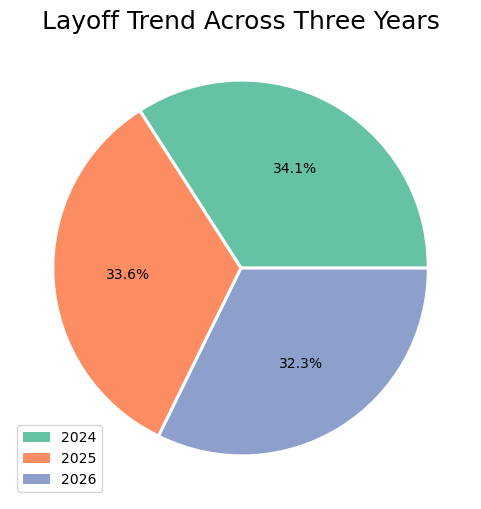

In [229]:
v1 = df['Year Of Exit'].value_counts()
plt.figure(figsize = (6,6))
plt.pie(v1, autopct = '%1.1f%%', colors = sns.color_palette('Set2'), explode = [0.01,0.01,0.01])
plt.title('Layoff Trend Across Three Years', fontsize = 18)
plt.legend(df['Year Of Exit'].unique(), loc = 'lower left')
plt.show()

2. Company-Wise Layoff Impact
   
    * The leadership team wants to identify which companies experienced the highest number of employee exits during the three-year period.
    * Present the comparison for management review.


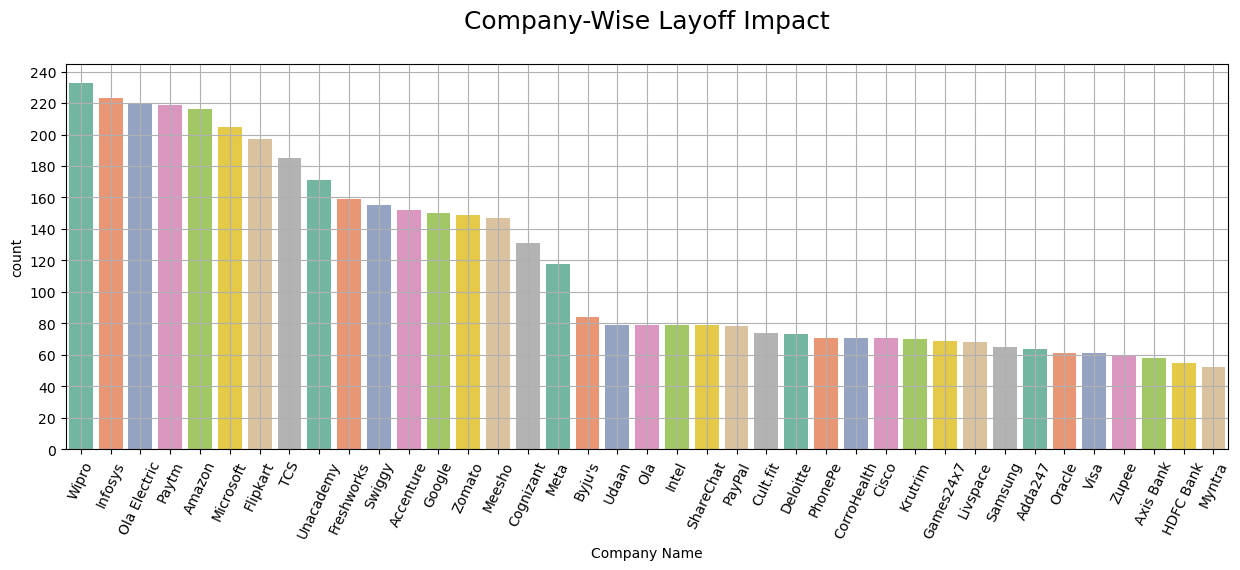

In [230]:
v2 = df['Company Name'].value_counts().reset_index()
plt.figure(figsize = (15,5))
sns.barplot(x = v2['Company Name'], y = v2['count'], palette='Set2')
plt.xticks(rotation = 65)
plt.yticks(np.arange(0,250,20).round())
plt.title('Company-Wise Layoff Impact\n', fontsize = 18)
plt.grid()
plt.show()

3. State-Wise Layoff Distribution

    * The HR leadership team wants to understand how employee exits were distributed across different states.
    * Present the geographical distribution of layoffs.


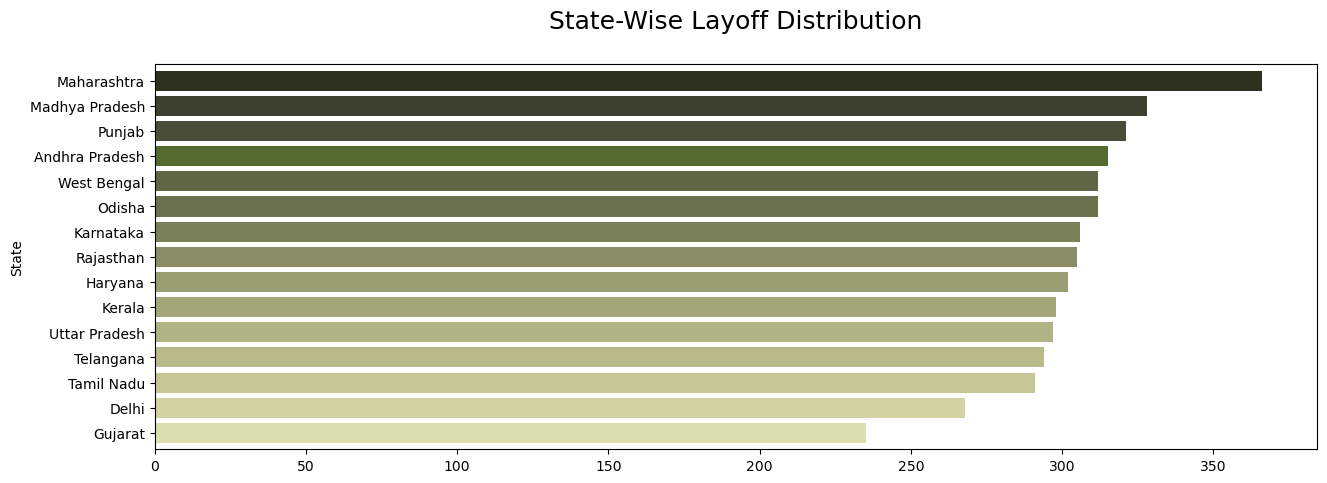

In [231]:
v3 = df['State'].value_counts().sort_values(ascending = True)
plt.figure(figsize = (15,5))
v3.plot.barh(color = ['#DCDFAF', '#D1D3A2', '#C4C696', '#B8BA8A', '#B0B384',
                      '#A3A678', '#9A9E73', '#8B8C68', '#7A805A', '#6B704F',
                      '#606646', '#556B2F', '#4A4E39', '#3D402E', '#2E301F'], width = 0.8)

plt.title('State-Wise Layoff Distribution\n', fontsize = 18)
plt.show()

4. Department-Wise Layoff Impact
    
    * The HR analytics team wants to identify which departments experienced the highest employee exits.
    * Present the department-wise impact of layoffs.

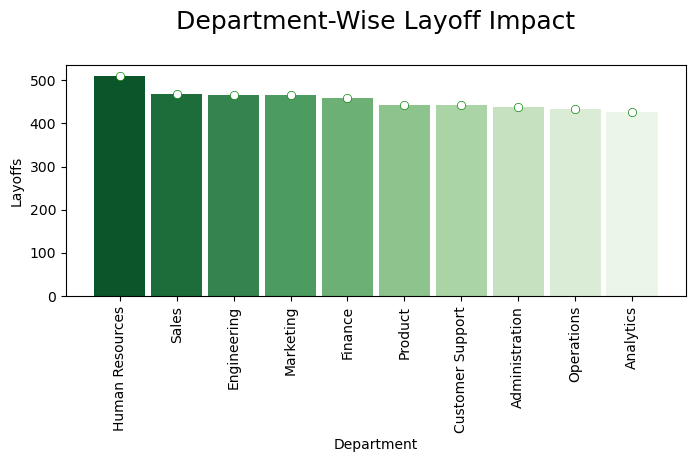

In [232]:
v4 = df['Department'].value_counts().reset_index()
v4.rename(columns={'count':'Layoffs'}, inplace = True)
plt.figure(figsize = (8,3))
sns.barplot(x = v4['Department'], y = v4['Layoffs'], palette='Greens_r', width = 0.9)
sns.scatterplot(x = v4['Department'], y = v4['Layoffs'], color = 'w', edgecolor = 'g')
plt.title('Department-Wise Layoff Impact\n', fontsize = 18)
plt.xticks(rotation = 90)
plt.show()

5. Performance and Layoffs
    
    * Management wants to examine average performance profile of employees who exited the organization under each branch.
    * Analyze the distribution of employee exits based on their performance ratings.


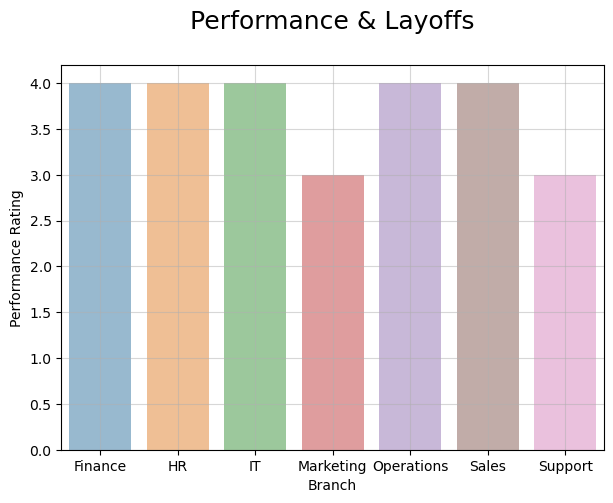

In [233]:
v5 = df.groupby('Branch')['Performance Rating'].mean().round().reset_index()
plt.figure(figsize = (7,5))
sns.barplot(x = v5['Branch'], y = v5['Performance Rating'], alpha = 0.5)
plt.title('Performance & Layoffs\n', fontsize = 18)
plt.grid(alpha = 0.5)
plt.show()

6. Work Mode and Atrrition Risk Analysis
   
    * Work Mode and Layoff Impact
        * The organization wants to understand whether employee exits were concentrated among different working arrangements.
        * Analyze layoffs across WFO, Hybrid, and Remote employees.        
    * Attrition Risk and Employee Exits
        * he HR analytics team wants to examine the attrition-risk profile of employees who exited the organization.
        * Present the distribution of exits across different attrition-risk levels.

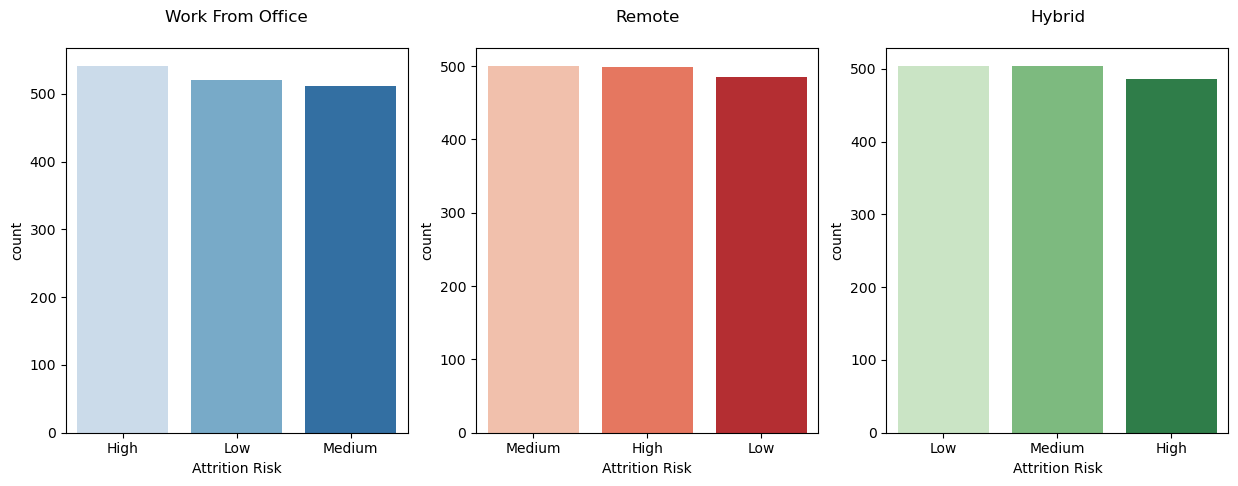

In [234]:
wfo = df[df['Work Mode']=='WFO']
remote = df[df['Work Mode']=='Remote']
hybrid = df[df['Work Mode']=='Hybrid']

wfo_risk = wfo['Attrition Risk'].value_counts().reset_index()
remote_risk = remote['Attrition Risk'].value_counts().reset_index()
hybrid_risk = hybrid['Attrition Risk'].value_counts().reset_index()

plt.figure(figsize = (15,5))

plt.subplot(1,3,1)
sns.barplot(x = wfo_risk['Attrition Risk'], y = wfo_risk['count'],palette = 'Blues')
plt.title('Work From Office\n')

plt.subplot(1,3,2)
sns.barplot(x = remote_risk['Attrition Risk'], y = remote_risk['count'], palette='Reds')
plt.title('Remote\n')

plt.subplot(1,3,3)
sns.barplot(x = hybrid_risk['Attrition Risk'], y = hybrid_risk['count'], palette='Greens')
plt.title('Hybrid\n')

plt.show()



7. Factors Associated With Employee Layoffs
   
    * The executive team wants a consolidated view of the employee characteristics associated with layoffs during the three-year period.
    * Analyze the data across reason, department, experience level, performance rating, work mode, attrition risk, and employee salary and present the major patterns visually.

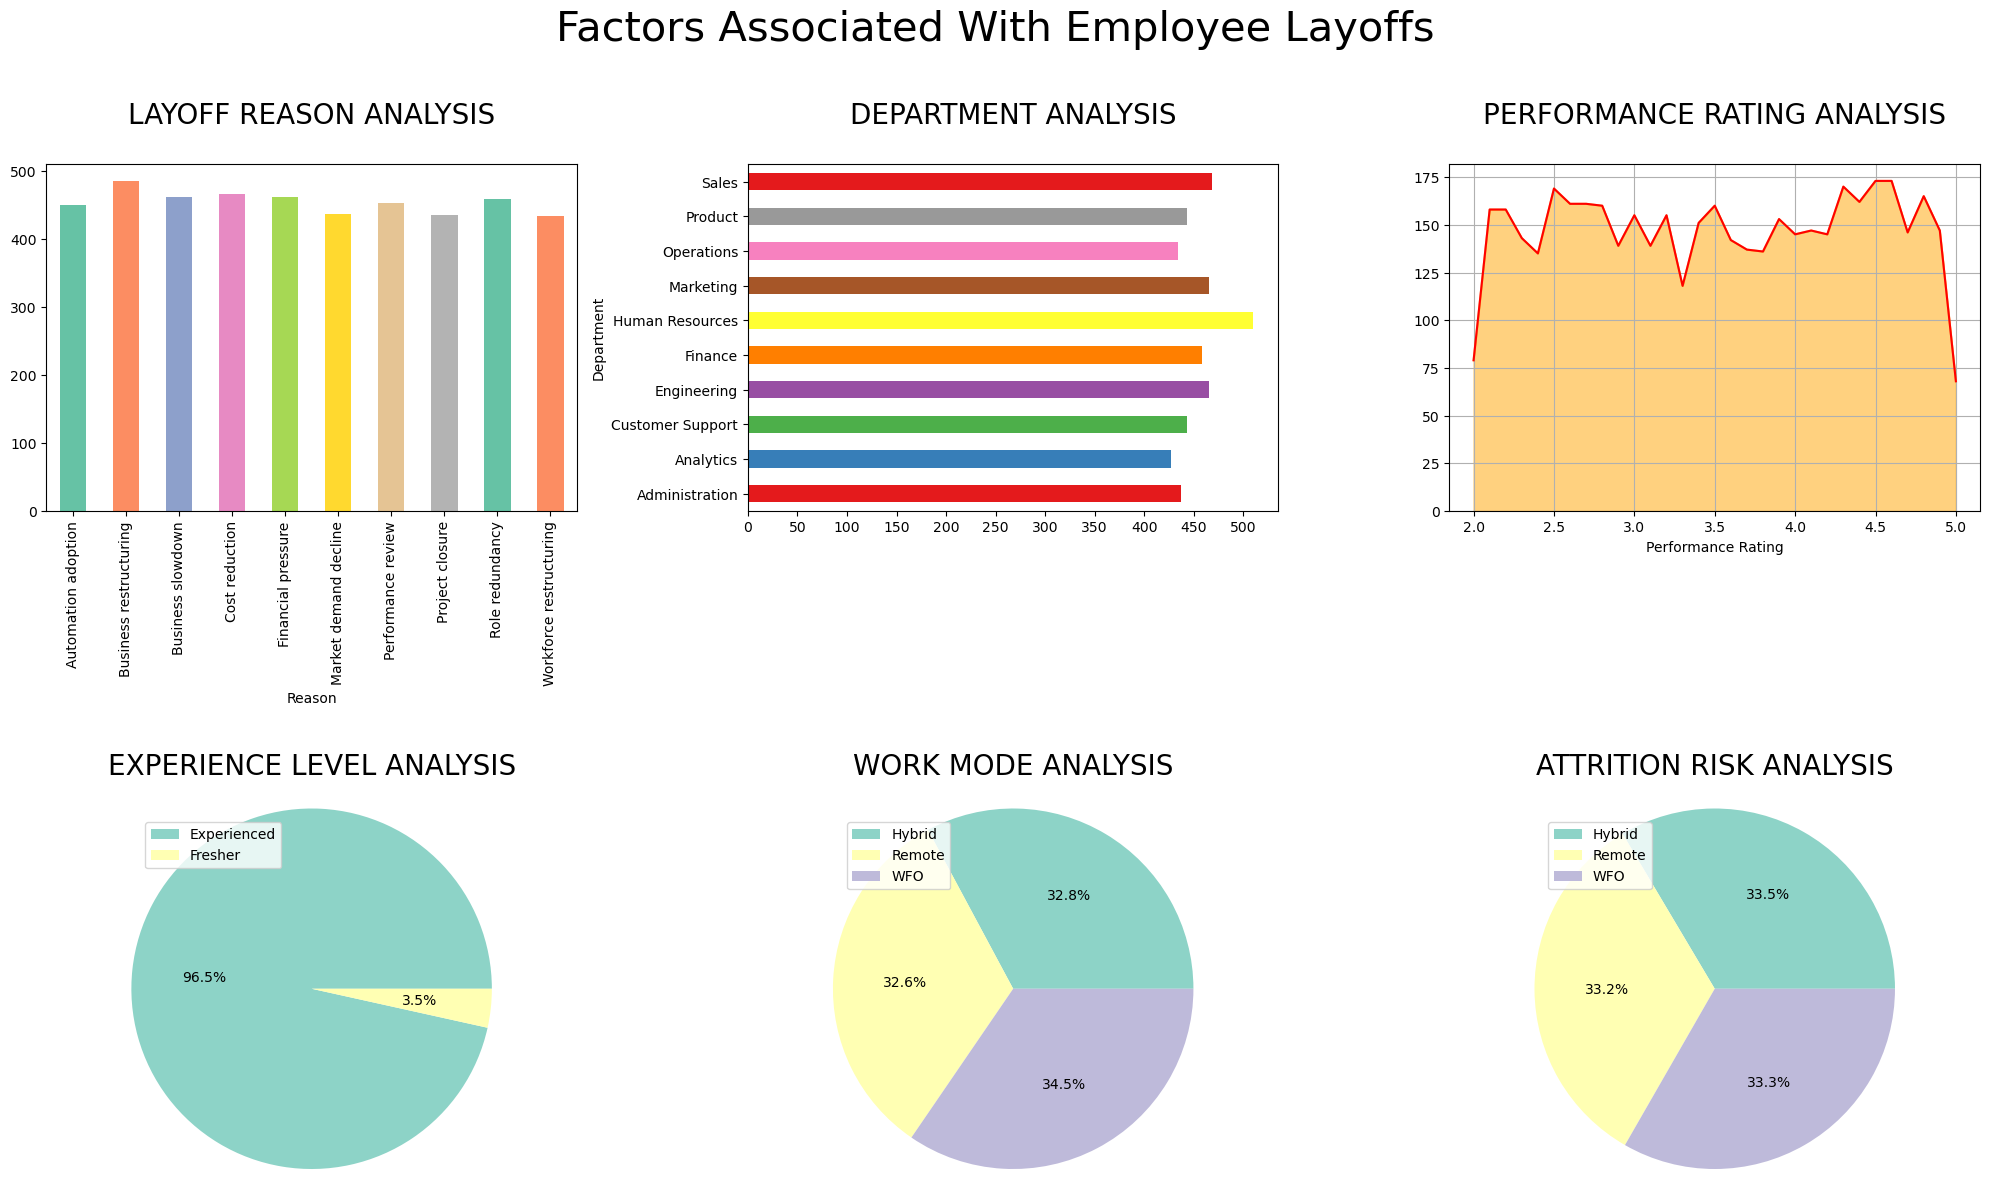

In [235]:
plt.figure(figsize = (20,12))

plt.suptitle('Factors Associated With Employee Layoffs\n', fontsize = 30)

plt.subplot(2,3,1)
vzn1 = df['Reason'].value_counts().sort_index()
vzn1.plot.bar(color = sns.color_palette('Set2'))
plt.title('LAYOFF REASON ANALYSIS\n', fontsize = 20)

plt.subplot(2,3,2)
vzn2 = df['Department'].value_counts().sort_index()
vzn2.plot.barh(color = sns.color_palette('Set1'))
plt.xticks(np.arange(0,550,50))
plt.title('DEPARTMENT ANALYSIS\n', fontsize = 20)

plt.subplot(2,3,3)
vzn3 = df['Performance Rating'].value_counts().sort_index()
vzn3.plot.area(alpha = 0.5, color = 'orange')
vzn3.plot.line(color = 'red')
plt.title('PERFORMANCE RATING ANALYSIS\n', fontsize = 20)
plt.grid()

plt.subplot(2,3,4)
vzn4 = df['Experience Level'].value_counts()
plt.pie(vzn4, colors = sns.color_palette('Set3'), radius = 1.3, autopct = '%1.1f%%')
plt.legend(vzn4.index, loc = 'upper left', fontsize = 10)
plt.title('\nEXPERIENCE LEVEL ANALYSIS\n', fontsize = 20)

plt.subplot(2,3,5)
vzn5 = df['Work Mode'].value_counts().sort_index()
plt.pie(vzn5, autopct = '%1.1f%%', radius = 1.3, colors = sns.color_palette('Set3'))
plt.legend(vzn5.index, loc = 'upper left')
plt.title('\nWORK MODE ANALYSIS\n', fontsize = 20)

plt.subplot(2,3,6)
vzn6 = df['Attrition Risk'].value_counts().sort_index()
plt.pie(vzn6, autopct = '%1.1f%%', radius = 1.3, colors = sns.color_palette('Set3'))
plt.legend(vzn5.index, loc = 'upper left')
plt.title('\nATTRITION RISK ANALYSIS\n', fontsize = 20)

plt.tight_layout()
plt.show()

# HIDE

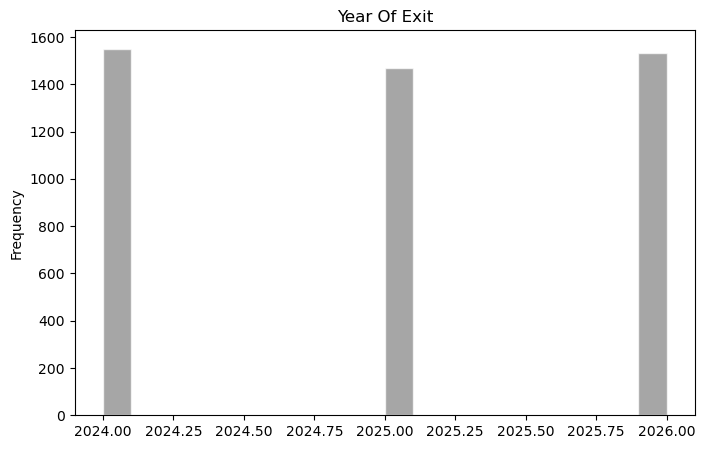

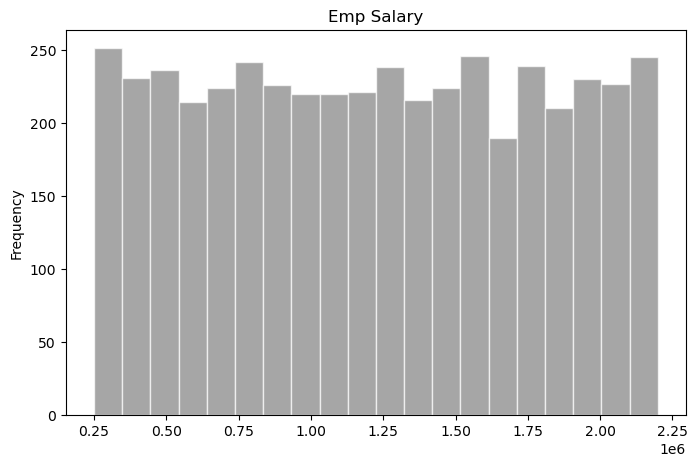

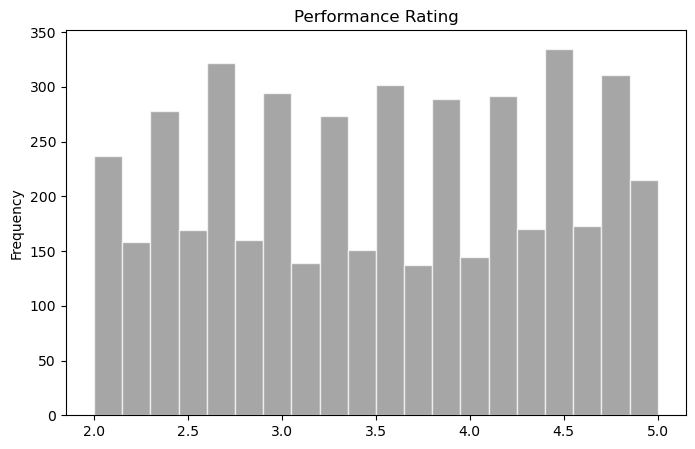

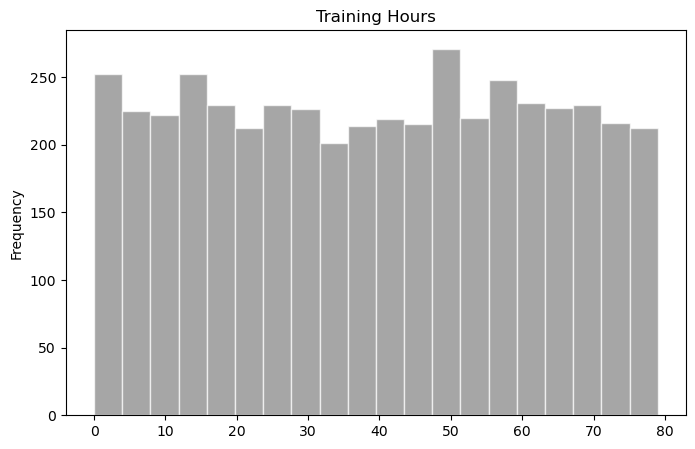

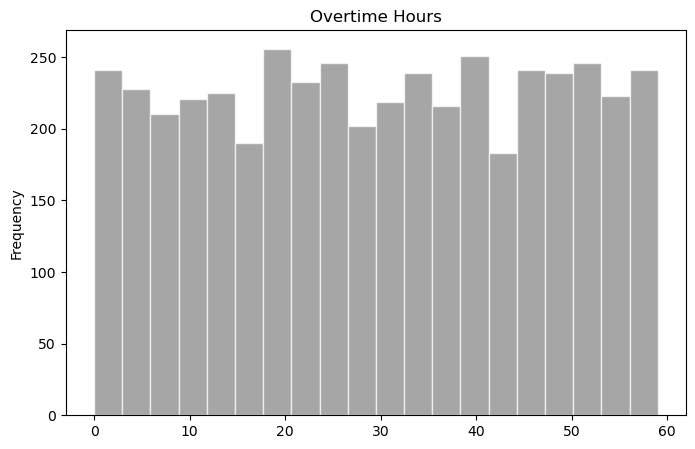

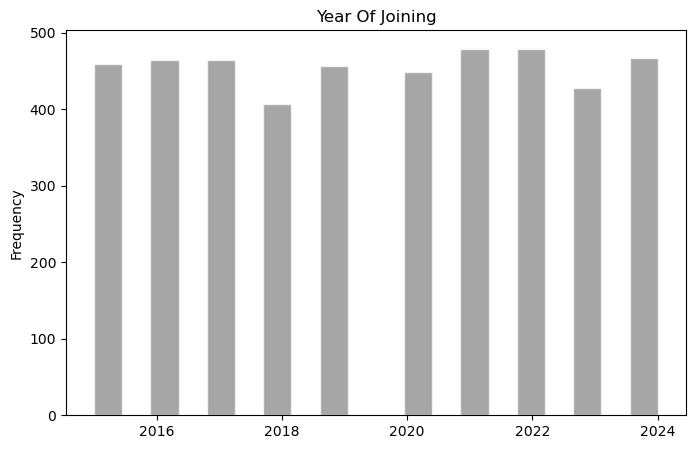

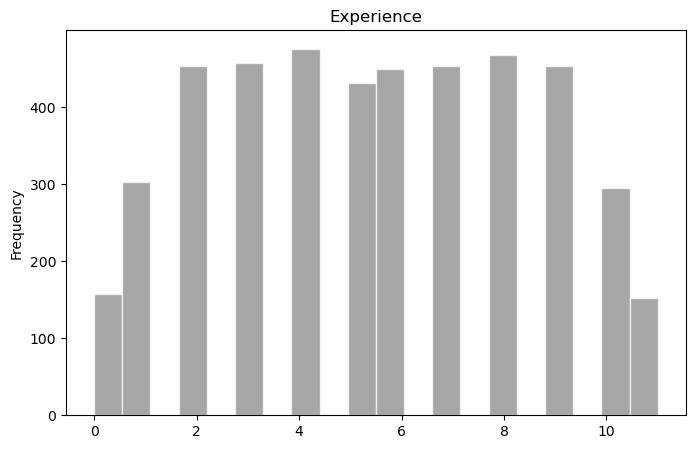

In [236]:
num_col = df.select_dtypes(np.number)
for col in num_col:
    plt.figure(figsize = (8,5))
    plt.subplot
    df[col].hist(bins = 20, edgecolor = 'w', color = 'Grey', alpha = 0.7)
    plt.title(col)
    plt.ylabel('Frequency')
    plt.grid(False)

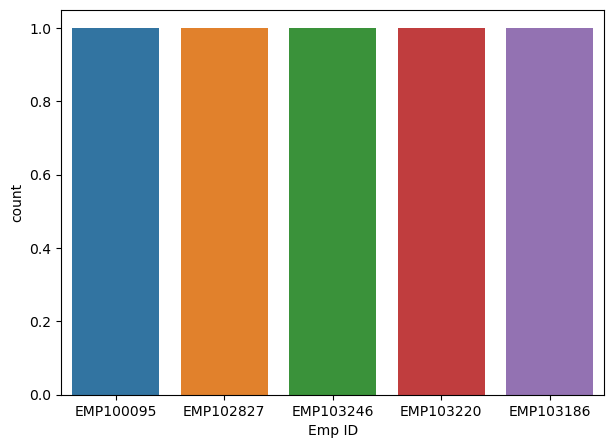

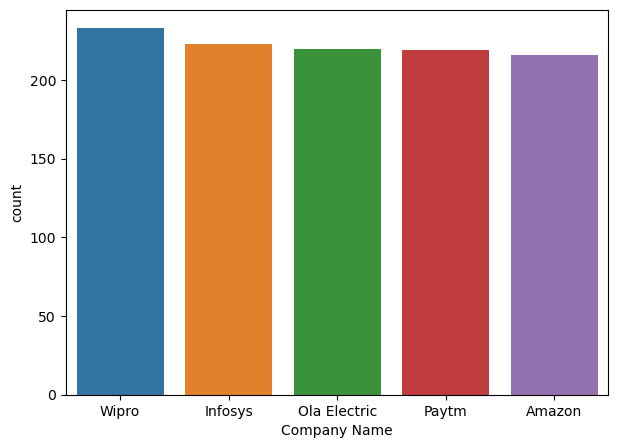

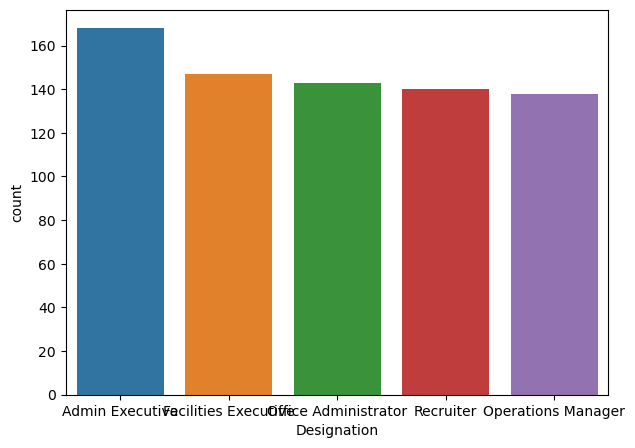

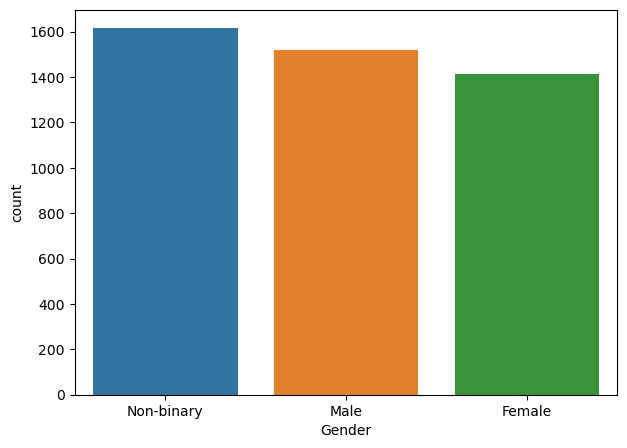

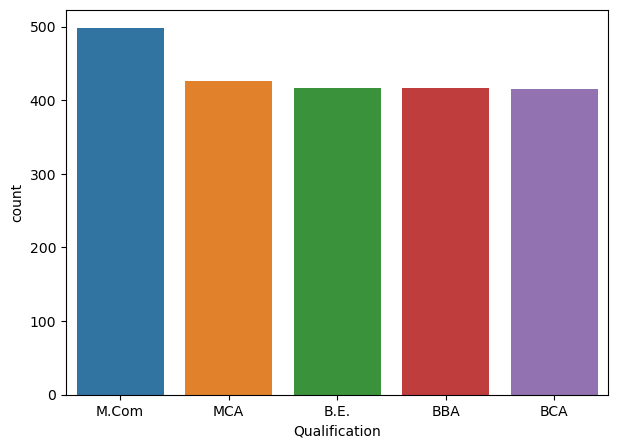

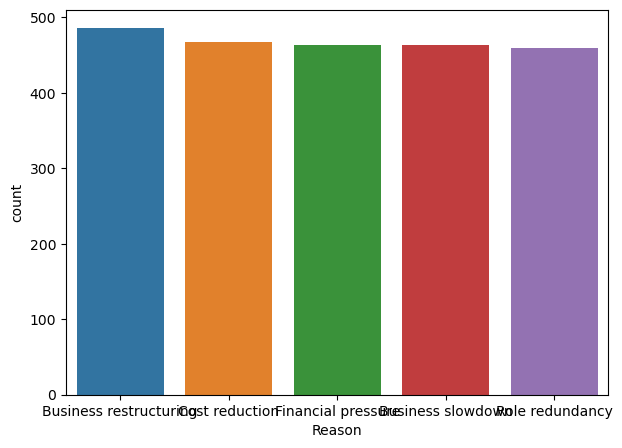

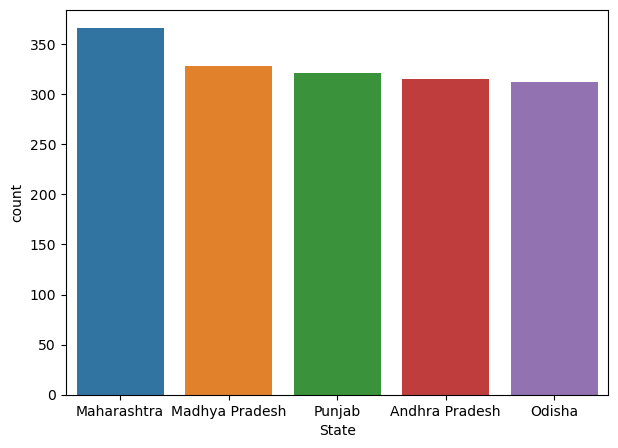

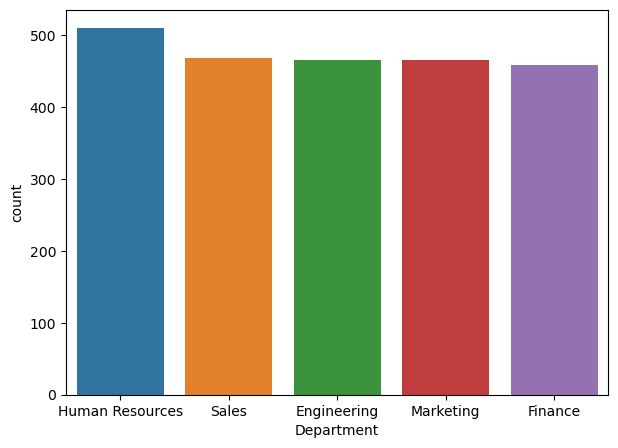

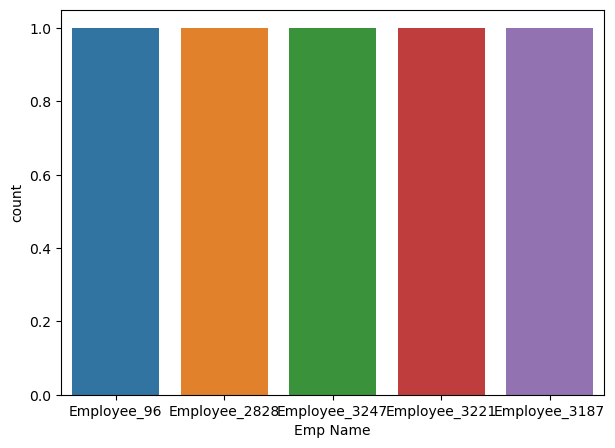

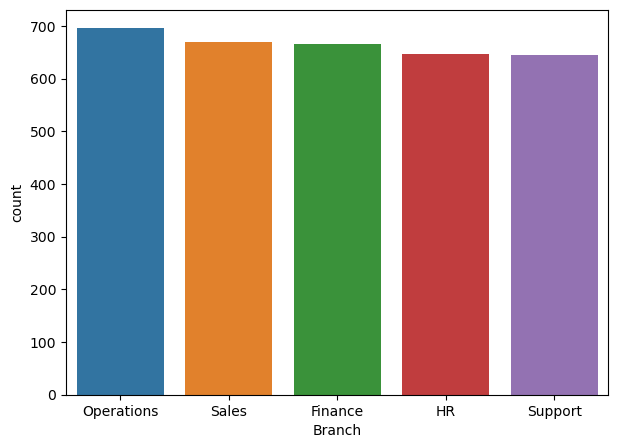

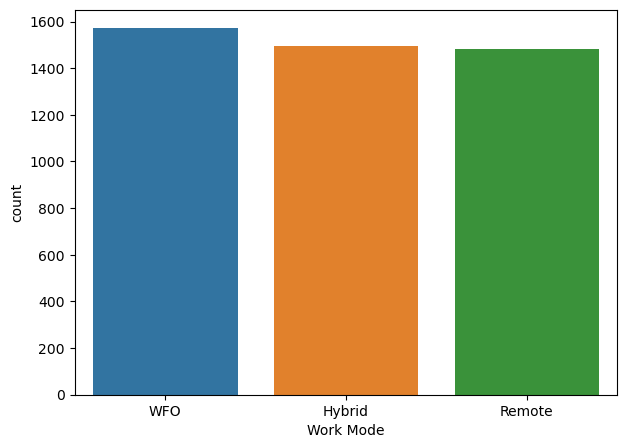

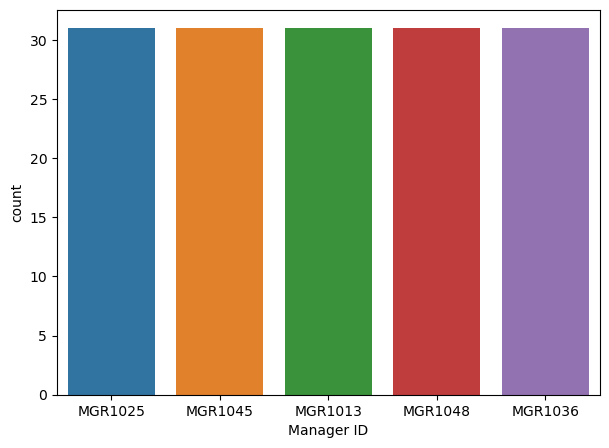

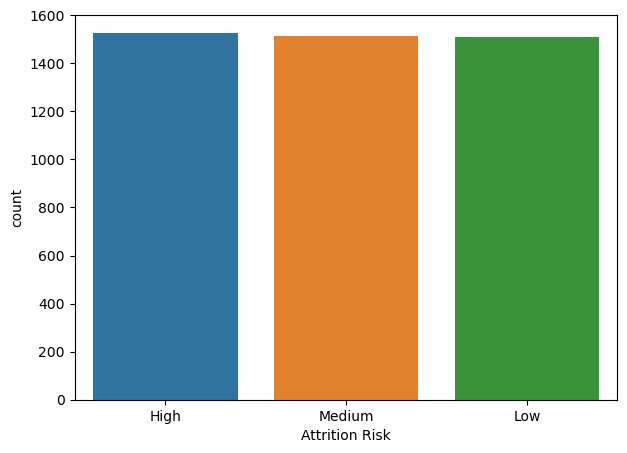

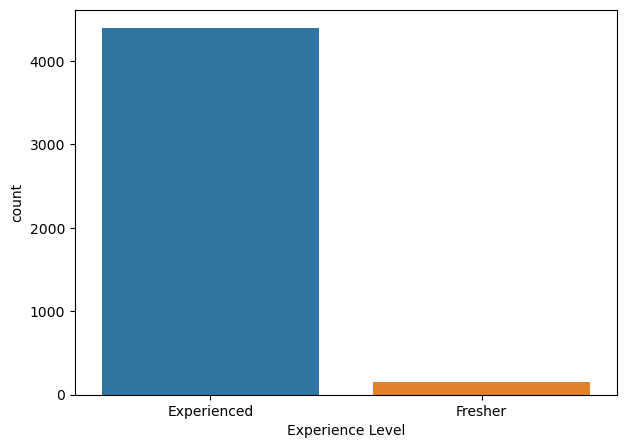

In [237]:
cat_col = df.select_dtypes('object')
for col_2 in cat_col:
    plt.figure(figsize=(7,5))
    sns.countplot(data =df, x = col_2, order = df[col_2].value_counts().head().index)